# Understanding the Quarterback Pocket
## A tracking-data analysis for offensive and defensive decision-makers

**Audience:** football staff and readers without an NFL analytics background  
**Data:** NFL Big Data Bowl tracking data, Weeks 1–8 of the 2021 season

This notebook extracts and visualizes **pocket situations**: how the offense creates protected space around the quarterback and how the defense compresses or penetrates it.

### Questions answered
1. What is a pocket, and who creates it?
2. How can we approximate pocket shape from player tracking?
3. When does a defender become a credible threat to the quarterback?
4. Do the tracking signals agree with PFF pressure labels?
5. How can offensive and defensive coordinators use this analysis?

## 1. Pocket terminology in plain language

The **offensive line forms the pocket** around its own quarterback. The defense does not form the pocket; defensive pass rushers try to **compress, penetrate, or collapse** it.

- The five core offensive linemen form the front and sides of the protected space.
- The quarterback starts behind them and normally drops farther from the line of scrimmage.
- Defensive rushers try to get around an edge or push through the middle.
- If the quarterback leaves the protected area, that is commonly called **leaving** or **breaking the pocket**. It may be forced by pressure or designed by the play call.

The diagram below is a simplified teaching picture, not a real play.

In [1]:
from pathlib import Path
from matplotlib.patches import Circle, Polygon

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 60)

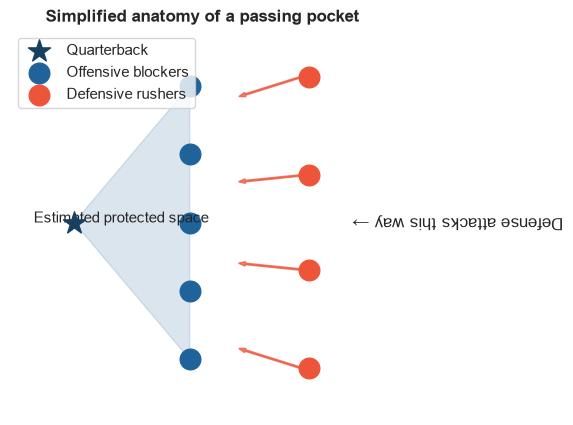

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
qb = np.array([1.5, 0.0])
blockers = np.array([[4.2, y] for y in [-3.2, -1.6, 0, 1.6, 3.2]])
rushers = np.array([[7.0, y] for y in [-3.4, -1.1, 1.1, 3.4]])

ax.add_patch(Polygon([qb, blockers[0], blockers[-1]], color="#20639B", alpha=0.16))
ax.scatter(*qb, s=280, marker="*", color="#173F5F", label="Quarterback", zorder=4)
ax.scatter(blockers[:, 0], blockers[:, 1], s=220, color="#20639B", label="Offensive blockers")
ax.scatter(rushers[:, 0], rushers[:, 1], s=220, color="#ED553B", label="Defensive rushers")
for x, y in rushers:
    ax.arrow(x - 0.2, y, -1.3, -0.12 * y, width=0.035, color="#ED553B", alpha=0.75)
ax.text(2.6, 0, "Estimated protected space", ha="center", fontsize=11)
ax.text(8.0, 0, "Defense attacks this way →", rotation=180, va="center")
ax.set(xlim=(0, 9), ylim=(-4.5, 4.5), title="Simplified anatomy of a passing pocket")
ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="upper left")
plt.show()

**How to read the diagram:** the blue triangle is an approximation of usable space between the quarterback and the outside blockers. In a real play, the shape bends, shifts, and may open on one side. The red defenders try to reduce that space and create a direct path to the quarterback.

## 2. Load the data

The extraction reads one game at a time. This keeps memory usage controlled while still analyzing all 122 games.

In [3]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "nfl-big-data-bowl-regional-event-data" / "data"
if not DATA_DIR.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_DIR = PROJECT_ROOT / "nfl-big-data-bowl-regional-event-data" / "data"

TRACKING_DIR = DATA_DIR / "tracking"
assert TRACKING_DIR.exists(), f"Tracking folder not found: {TRACKING_DIR}"

In [4]:
games = pd.read_csv(DATA_DIR / "games.csv")
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking_files = sorted(TRACKING_DIR.glob("tracking_*.csv"))

print(f"{len(games):,} games | {len(plays):,} plays | {len(tracking_files):,} tracking files")

122 games | 8,557 plays | 122 tracking files


## 3. An explainable pocket approximation

A pocket boundary is **not directly labeled** in the dataset, so we estimate it with transparent rules:

1. Flip left-moving plays so the offense always moves from left to right.
2. Use PFF roles to identify the quarterback, pass rushers, and five core linemen (`LT`, `LG`, `C`, `RG`, `RT`).
3. Measure **pocket width** as the lateral distance between the widest core blockers.
4. Measure **front cushion** as the downfield distance between the quarterback and the average core blocker position.
5. Approximate **pocket space** as a triangle: `width × front cushion ÷ 2`.
6. Mark a **threat** when the nearest pass rusher comes within 2.5 yards of the quarterback.

The 2.5-yard boundary is an exploratory reference—not an official NFL or PFF definition. It should eventually be calibrated using film review and PFF pressure outcomes.

In [5]:
PLAY_KEYS = ["gameId", "playId"]
FRAME_KEYS = PLAY_KEYS + ["frameId"]
CORE_LINE_POSITIONS = ["LT", "LG", "C", "RG", "RT"]
THREAT_RADIUS_YARDS = 2.5
MAX_POCKET_SECONDS = 5.0
END_EVENTS = ["pass_forward", "autoevent_passforward", "qb_sack", "run"]
TRACKING_COLUMNS = [
    "gameId", "playId", "nflId", "frameId", "team", "playDirection",
    "x", "y", "s", "dir", "o", "event",
]

### 3.1 Isolate the pocket phase

For each play, we start at the snap and stop at the throw, sack, declared run, or five seconds—whichever comes first. This prevents post-throw movement from being mistaken for pocket behavior.

In [6]:
def first_event_frame(data, events, name):
    """Return the first tagged frame for each play."""
    return (data.loc[data["event"].isin(events)]
            .groupby(PLAY_KEYS)["frameId"].min()
            .rename(name))

In [7]:
def prepare_play_window(tracking):
    actual_snap = first_event_frame(tracking, ["ball_snap"], "snap_frame")
    auto_snap = first_event_frame(tracking, ["autoevent_ballsnap"], "snap_frame")
    snap = actual_snap.combine_first(auto_snap).rename("snap_frame")
    end = first_event_frame(tracking, END_EVENTS, "end_frame")
    last = tracking.groupby(PLAY_KEYS)["frameId"].max().rename("last_frame")

    timing = pd.concat([snap, end, last], axis=1).dropna(subset=["snap_frame"])
    timing["end_frame"] = timing["end_frame"].fillna(timing["last_frame"])
    cap = timing["snap_frame"] + MAX_POCKET_SECONDS * 10
    timing["end_frame"] = np.minimum(timing["end_frame"], cap)

    window = tracking.merge(timing.reset_index(), on=PLAY_KEYS, how="inner")
    window = window[window["frameId"].between(window["snap_frame"], window["end_frame"])].copy()
    window["seconds_after_snap"] = (window["frameId"] - window["snap_frame"]) / 10
    window["x_standard"] = np.where(window["playDirection"].eq("right"), window["x"], 120 - window["x"])
    return window

### 3.2 Locate the quarterback, nearest rusher, and blocker wall

These small functions keep each football concept separate and inspectable.

In [8]:
def quarterback_frames(window, roles):
    passer_ids = roles.loc[roles["pff_role"].eq("Pass"), PLAY_KEYS + ["nflId"]]
    qb = window.merge(passer_ids, on=PLAY_KEYS + ["nflId"], how="inner")
    return qb[FRAME_KEYS + ["seconds_after_snap", "x_standard", "y"]].rename(
        columns={"x_standard": "qb_x", "y": "qb_y"}
    )

In [9]:
def nearest_rusher_frames(window, roles, qb):
    rusher_ids = roles.loc[roles["pff_role"].eq("Pass Rush"), PLAY_KEYS + ["nflId"]]
    rush = window.merge(rusher_ids, on=PLAY_KEYS + ["nflId"], how="inner")
    rush = rush.merge(qb[FRAME_KEYS + ["qb_x", "qb_y"]], on=FRAME_KEYS)
    rush["rusher_distance"] = np.hypot(
        rush["x_standard"] - rush["qb_x"], rush["y"] - rush["qb_y"]
    )
    nearest_index = rush.groupby(FRAME_KEYS)["rusher_distance"].idxmin()
    nearest = rush.loc[nearest_index, FRAME_KEYS + ["nflId", "rusher_distance"]]
    return nearest.rename(columns={"nflId": "nearest_rusher_id"})

In [10]:
def blocker_geometry(window, roles):
    core_ids = roles.loc[
        roles["pff_role"].eq("Pass Block")
        & roles["pff_positionLinedUp"].isin(CORE_LINE_POSITIONS),
        PLAY_KEYS + ["nflId"],
    ]
    blockers = window.merge(core_ids, on=PLAY_KEYS + ["nflId"], how="inner")
    shape = blockers.groupby(FRAME_KEYS).agg(
        left_edge_y=("y", "min"), right_edge_y=("y", "max"),
        blocker_wall_x=("x_standard", "mean"), core_blockers=("nflId", "nunique"),
    ).reset_index()
    shape["pocket_width"] = shape["right_edge_y"] - shape["left_edge_y"]
    return shape

In [11]:
def extract_pocket_frames(tracking, roles):
    window = prepare_play_window(tracking)
    qb = quarterback_frames(window, roles)
    nearest = nearest_rusher_frames(window, roles, qb)
    shape = blocker_geometry(window, roles)

    frames = qb.merge(nearest, on=FRAME_KEYS).merge(shape, on=FRAME_KEYS)
    frames["front_cushion"] = (frames["blocker_wall_x"] - frames["qb_x"]).clip(lower=0)
    frames["estimated_pocket_area"] = frames["pocket_width"] * frames["front_cushion"] / 2
    return frames.sort_values(FRAME_KEYS)

### 3.3 Convert frame-by-frame movement into one row per play

We retain the minimum rusher distance, first threat time, maximum quarterback lateral movement, and pocket measurements at common time checkpoints.

In [12]:
def summarize_pocket_frames(frames):
    base = frames.groupby(PLAY_KEYS).agg(
        pocket_duration=("seconds_after_snap", "max"),
        minimum_rusher_distance=("rusher_distance", "min"),
    ).reset_index()
    threat = (frames.loc[frames["rusher_distance"].le(THREAT_RADIUS_YARDS)]
              .groupby(PLAY_KEYS)["seconds_after_snap"].min()
              .rename("time_to_threat").reset_index())

    snap = frames.loc[np.isclose(frames["seconds_after_snap"], 0),
                      PLAY_KEYS + ["qb_y", "pocket_width", "front_cushion", "estimated_pocket_area"]]
    snap = snap.rename(columns={"qb_y": "snap_qb_y", "pocket_width": "initial_width",
                                "front_cushion": "initial_cushion",
                                "estimated_pocket_area": "initial_area"})
    movement = frames.merge(snap[PLAY_KEYS + ["snap_qb_y"]], on=PLAY_KEYS)
    movement["lateral_move"] = (movement["qb_y"] - movement["snap_qb_y"]).abs()
    max_move = movement.groupby(PLAY_KEYS)["lateral_move"].max().rename("max_qb_lateral_move").reset_index()
    return base.merge(threat, on=PLAY_KEYS, how="left").merge(snap, on=PLAY_KEYS).merge(max_move, on=PLAY_KEYS)

In [13]:
def add_time_checkpoints(summary, frames, checkpoints=(1.0, 2.0, 2.5, 3.0)):
    measurements = ["rusher_distance", "pocket_width", "front_cushion", "estimated_pocket_area"]
    result = summary.copy()
    for second in checkpoints:
        label = str(second).replace(".", "_") + "s"
        point = frames.loc[np.isclose(frames["seconds_after_snap"], second), PLAY_KEYS + measurements]
        point = point.rename(columns={column: f"{column}_{label}" for column in measurements})
        result = result.merge(point, on=PLAY_KEYS, how="left")
    return result

## 4. Extract pocket measurements for all games

Only the compact play-level results are retained after each file, so the full set of tracking rows is never held in memory at once. Runtime depends on the computer but is normally a few minutes or less for this dataset.

In [14]:
roles_by_game = {game_id: group for game_id, group in pff.groupby("gameId")}
metric_parts = []

for number, path in enumerate(tracking_files, start=1):
    game_id = int(path.stem.removeprefix("tracking_"))
    tracking = pd.read_csv(path, usecols=TRACKING_COLUMNS)
    frame_metrics = extract_pocket_frames(tracking, roles_by_game[game_id])
    play_metrics = summarize_pocket_frames(frame_metrics)
    metric_parts.append(add_time_checkpoints(play_metrics, frame_metrics))
    if number % 20 == 0 or number == len(tracking_files):
        print(f"Processed {number:>3}/{len(tracking_files)} games")

pocket_metrics = pd.concat(metric_parts, ignore_index=True)

Processed  20/122 games


Processed  40/122 games


Processed  60/122 games


Processed  80/122 games


Processed 100/122 games


Processed 120/122 games
Processed 122/122 games


### Add play context and PFF pressure outcomes

A PFF pressure means at least one rusher received a hurry, hit, or sack credit on the play. We use this expert label to check whether our simple tracking signal behaves sensibly.

In [15]:
pressure_columns = ["pff_hurry", "pff_hit", "pff_sack"]
rush_labels = pff.loc[pff["pff_role"].eq("Pass Rush"), PLAY_KEYS + pressure_columns].copy()
rush_labels[pressure_columns] = rush_labels[pressure_columns].fillna(0)
rush_labels["pff_pressure"] = rush_labels[pressure_columns].max(axis=1)
play_pressure = rush_labels.groupby(PLAY_KEYS)["pff_pressure"].max().reset_index()

In [16]:
context_columns = PLAY_KEYS + [
    "playDescription", "down", "yardsToGo", "possessionTeam", "defensiveTeam",
    "absoluteYardlineNumber", "offenseFormation", "dropBackType", "pff_playAction",
    "pff_passCoverage", "passResult", "playResult",
]
pocket_plays = pocket_metrics.merge(plays[context_columns], on=PLAY_KEYS, how="left")
pocket_plays = pocket_plays.merge(play_pressure, on=PLAY_KEYS, how="left")
pocket_plays["pff_pressure"] = pocket_plays["pff_pressure"].fillna(0).astype(int)
pocket_plays["early_threat"] = pocket_plays["time_to_threat"].le(2.5)
pocket_plays["sack"] = pocket_plays["passResult"].eq("S")

print(f"Pocket metrics extracted for {len(pocket_plays):,} of {len(plays):,} plays ({len(pocket_plays) / len(plays):.1%}).")

Pocket metrics extracted for 8,532 of 8,557 plays (99.7%).


### Analysis scope

Designed rollouts and scrambles intentionally move the quarterback away from a conventional pocket. The main validation charts therefore use **traditional dropbacks**. Those movement plays remain in `pocket_plays` and can be analyzed separately.

In [17]:
dropback_counts = pocket_plays["dropBackType"].fillna("Missing / unclassified").value_counts()
traditional = pocket_plays.loc[pocket_plays["dropBackType"].eq("TRADITIONAL")].copy()

pd.DataFrame({
    "Pocket plays extracted": [len(pocket_plays)],
    "Traditional dropbacks used below": [len(traditional)],
    "Designed rollouts": [pocket_plays["dropBackType"].str.startswith("DESIGNED_ROLLOUT", na=False).sum()],
    "Scramble categories": [pocket_plays["dropBackType"].str.contains("SCRAMBLE", na=False).sum()],
})

,Pocket plays extracted,Traditional dropbacks used below,Designed rollouts,Scramble categories
0,8532,6524,434,1041


## 5. Watch an example pocket collapse

We select a representative traditional sack whose threat time is near the median sack threat time. This avoids choosing only the most extreme play. All plays are flipped, when necessary, so the offense moves to the right.

In [18]:
sack_examples = traditional.loc[traditional["sack"] & traditional["time_to_threat"].notna()]
median_sack_threat = sack_examples["time_to_threat"].median()
demo_index = (sack_examples["time_to_threat"] - median_sack_threat).abs().idxmin()
demo = sack_examples.loc[demo_index]
DEMO_GAME_ID, DEMO_PLAY_ID = int(demo["gameId"]), int(demo["playId"])

demo[["playDescription", "down", "yardsToGo", "offenseFormation",
      "pff_passCoverage", "pocket_duration", "time_to_threat"]].to_frame("Value")

,Value
playDescription,(5:45) (Shotgun) M.Ryan sacked at ATL 22 for -...
down,4
yardsToGo,10
offenseFormation,EMPTY
pff_passCoverage,Cover-2
pocket_duration,4.0
time_to_threat,2.4


In [19]:
demo_tracking = pd.read_csv(TRACKING_DIR / f"tracking_{DEMO_GAME_ID}.csv", usecols=TRACKING_COLUMNS)
demo_roles = roles_by_game[DEMO_GAME_ID]
demo_window = prepare_play_window(demo_tracking)
demo_frames = extract_pocket_frames(demo_tracking, demo_roles)

role_columns = PLAY_KEYS + ["nflId", "pff_role", "pff_positionLinedUp"]
demo_players = demo_window.loc[demo_window["playId"].eq(DEMO_PLAY_ID)].merge(
    demo_roles[role_columns], on=PLAY_KEYS + ["nflId"], how="left"
)
demo_frame_metrics = demo_frames.loc[demo_frames["playId"].eq(DEMO_PLAY_ID)]

### Four snapshots from snap to sack

- **Blue circles:** the five core offensive linemen
- **Blue star:** the quarterback
- **Red circles:** pass rushers
- **Light-blue triangle:** the estimated pocket space
- **Red ring:** the exploratory 2.5-yard threat boundary

Receivers and coverage defenders are hidden in this diagram so the pocket interaction remains easy to see.

In [20]:
def draw_pocket_field(ax, line_of_scrimmage, x_limits, y_limits):
    ax.set_facecolor("#E8F3E8")
    for yard in range(0, 121, 5):
        ax.axvline(yard, color="white", linewidth=0.7, alpha=0.8, zorder=0)
    ax.axvline(line_of_scrimmage, color="#F6D55C", linestyle="--", linewidth=2)
    ax.set(xlim=x_limits, ylim=y_limits, xlabel="Standardized field position", ylabel="Field width")
    ax.set_aspect("equal")

In [21]:
def draw_pocket_snapshot(ax, play_data, target_second, line_of_scrimmage, limits):
    frame_id = play_data.loc[(play_data["seconds_after_snap"] - target_second).abs().idxmin(), "frameId"]
    frame = play_data.loc[play_data["frameId"].eq(frame_id)]
    qb = frame.loc[frame["pff_role"].eq("Pass")]
    blockers = frame.loc[frame["pff_positionLinedUp"].isin(CORE_LINE_POSITIONS)]
    rushers = frame.loc[frame["pff_role"].eq("Pass Rush")]

    draw_pocket_field(ax, line_of_scrimmage, *limits)
    qx, qy = qb.iloc[0][["x_standard", "y"]]
    outside = blockers.loc[[blockers["y"].idxmin(), blockers["y"].idxmax()]]
    triangle = [[qx, qy], *outside[["x_standard", "y"]].to_numpy()]
    ax.add_patch(Polygon(triangle, color="#20639B", alpha=0.18, zorder=1))
    ax.add_patch(Circle((qx, qy), THREAT_RADIUS_YARDS, fill=False, color="#ED553B", linestyle="--"))
    ax.scatter(blockers["x_standard"], blockers["y"], s=120, color="#20639B", edgecolor="black", zorder=3)
    ax.scatter(rushers["x_standard"], rushers["y"], s=120, color="#ED553B", edgecolor="black", zorder=3)
    ax.scatter(qx, qy, s=220, marker="*", color="#173F5F", edgecolor="black", zorder=4)
    ax.set_title(f"{target_second:.1f}s after snap")

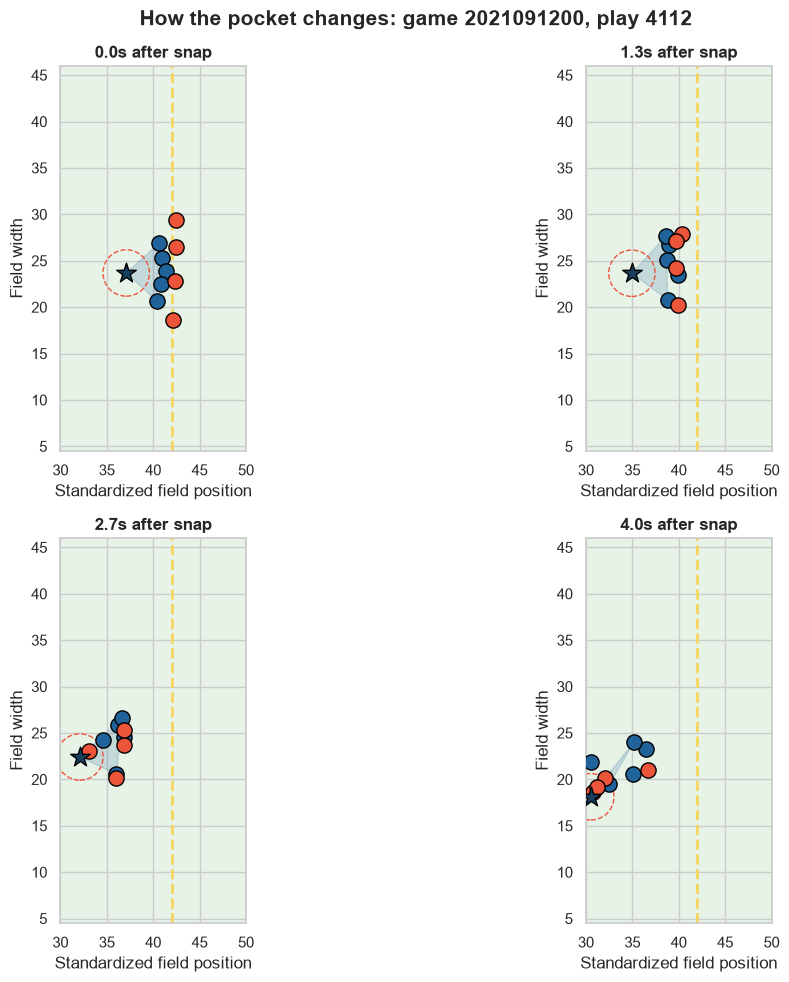

In [22]:
play_direction = demo_players["playDirection"].mode().iloc[0]
raw_los = float(demo["absoluteYardlineNumber"])
standard_los = raw_los if play_direction == "right" else 120 - raw_los
y_limits = (demo_players["y"].min() - 2, demo_players["y"].max() + 2)
limits = ((standard_los - 12, standard_los + 8), y_limits)
times = np.linspace(0, float(demo["pocket_duration"]), 4)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, second in zip(axes.flat, times):
    draw_pocket_snapshot(ax, demo_players, second, standard_los, limits)
fig.suptitle(f"How the pocket changes: game {DEMO_GAME_ID}, play {DEMO_PLAY_ID}", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**What changes over time:** the quarterback drops behind the blocker wall while the rushers close in. A healthy pocket creates enough width and front cushion for the quarterback to operate. A collapse occurs when that usable space disappears or a rusher enters the quarterback's immediate threat area. The shaded triangle is deliberately simple; it makes the idea visible but is not a final grading boundary.

### The same play as two simple timelines

The first chart shows the distance from the quarterback to the nearest rusher. The second shows the dimensions of the estimated pocket.

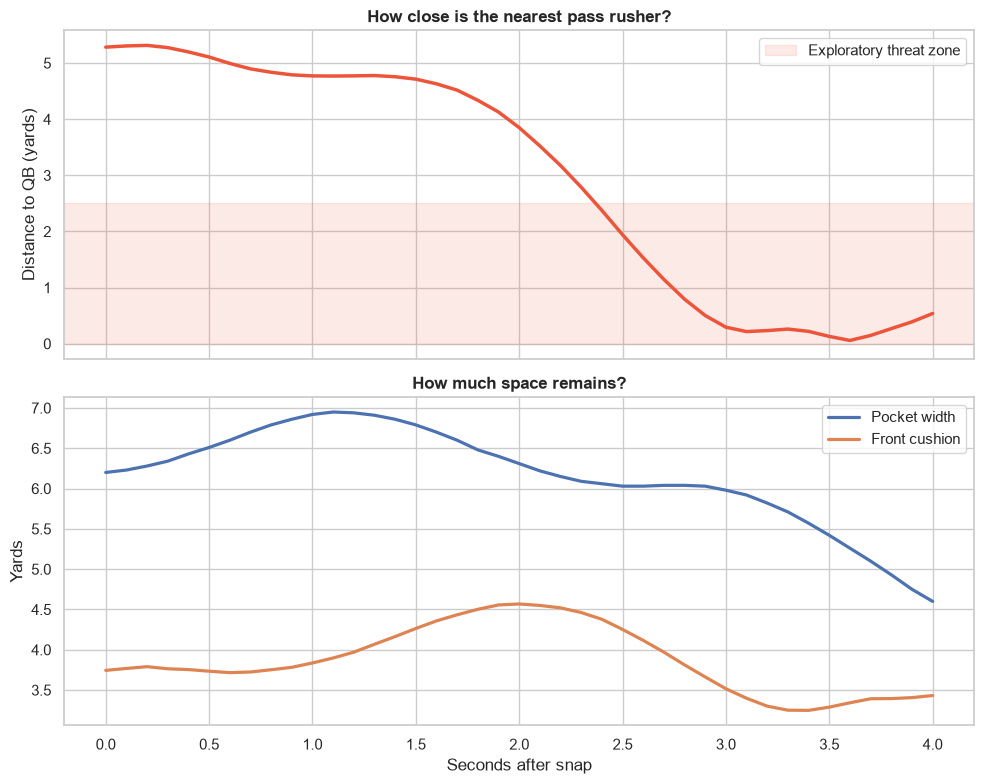

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
t = demo_frame_metrics["seconds_after_snap"]

axes[0].plot(t, demo_frame_metrics["rusher_distance"], color="#ED553B", linewidth=2.5)
axes[0].axhspan(0, THREAT_RADIUS_YARDS, color="#ED553B", alpha=0.12, label="Exploratory threat zone")
axes[0].set(title="How close is the nearest pass rusher?", ylabel="Distance to QB (yards)")
axes[0].legend()

axes[1].plot(t, demo_frame_metrics["pocket_width"], label="Pocket width", linewidth=2.3)
axes[1].plot(t, demo_frame_metrics["front_cushion"], label="Front cushion", linewidth=2.3)
axes[1].set(title="How much space remains?", xlabel="Seconds after snap", ylabel="Yards")
axes[1].legend()
plt.tight_layout()
plt.show()

**Plain-language reading:** a falling red line means a defender is closing on the quarterback. Pocket width and front cushion explain whether the pressure is arriving around an edge or through the middle. A final model should identify those lanes separately rather than compressing everything into one number.

## 6. Does the simple threat signal match expert pressure labels?

These charts use all extracted traditional dropbacks. Agreement does not prove that the threshold is perfect, but it tells us whether the tracking signal points in a sensible direction.

### 6.1 When does the first nearby threat arrive?

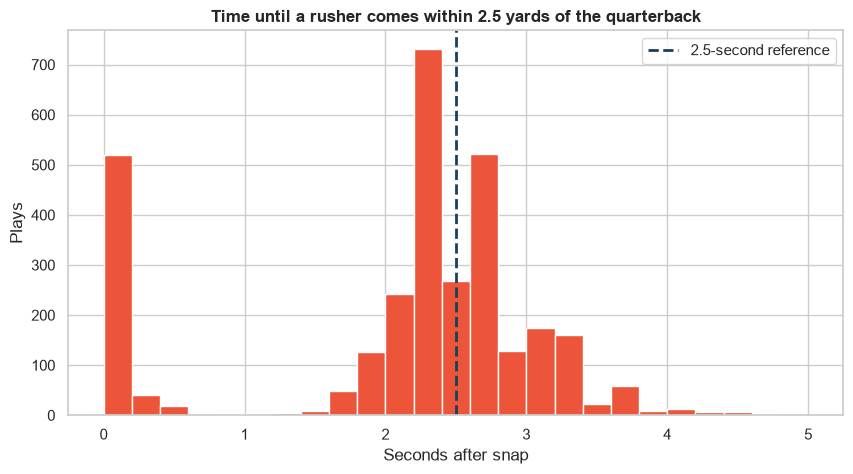

In [24]:
threat_times = traditional["time_to_threat"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(threat_times, bins=np.arange(0, 5.1, 0.2), color="#ED553B", edgecolor="white")
ax.axvline(2.5, color="#173F5F", linestyle="--", linewidth=2, label="2.5-second reference")
ax.set(title="Time until a rusher comes within 2.5 yards of the quarterback",
       xlabel="Seconds after snap", ylabel="Plays")
ax.legend()
plt.show()

**How to use this:** early threats matter more because they disrupt quick and normal-timing passes. A threat after three or four seconds may reflect a long-developing play or the quarterback holding the ball, rather than an immediate protection failure.

### 6.2 Rusher distance at two seconds: pressured vs. non-pressured plays

Only plays that still have an active pocket phase at two seconds are included.

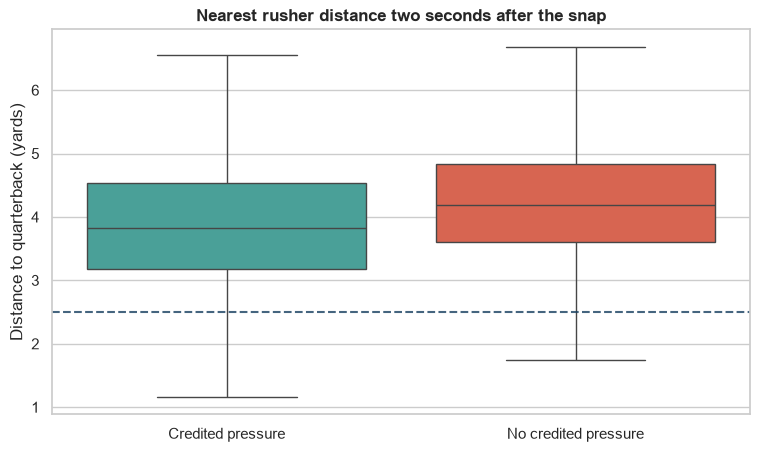

In [25]:
distance_two = traditional.loc[traditional["rusher_distance_2_0s"].notna()].copy()
distance_two["PFF result"] = distance_two["pff_pressure"].map({0: "No credited pressure", 1: "Credited pressure"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=distance_two, x="PFF result", y="rusher_distance_2_0s",
            hue="PFF result", palette=["#3CAEA3", "#ED553B"], legend=False, showfliers=False, ax=ax)
ax.axhline(THREAT_RADIUS_YARDS, color="#173F5F", linestyle="--", alpha=0.8)
ax.set(title="Nearest rusher distance two seconds after the snap",
       xlabel="", ylabel="Distance to quarterback (yards)")
plt.show()

**How to read a box plot:** the line inside each box is the typical (median) play, and the box contains the middle half of plays. If the pressure box is lower, rushers are generally closer to the quarterback on plays that film graders identify as pressures. Overlap is expected because pressure depends on angle, blocker control, quarterback movement, and timing—not distance alone.

### 6.3 What happens after an early threat?

An **early threat** means the nearest rusher entered the 2.5-yard reference area within 2.5 seconds.

In [26]:
traditional["Pocket status"] = np.where(traditional["early_threat"], "Early nearby threat", "No early nearby threat")
status_rates = traditional.groupby("Pocket status").agg(
    plays=("playId", "size"),
    pff_pressure_rate=("pff_pressure", "mean"),
    sack_rate=("sack", "mean"),
).reset_index()
status_rates

,Pocket status,plays,pff_pressure_rate,sack_rate
0,Early nearby threat,2017,0.553297,0.141795
1,No early nearby threat,4507,0.209452,0.034169


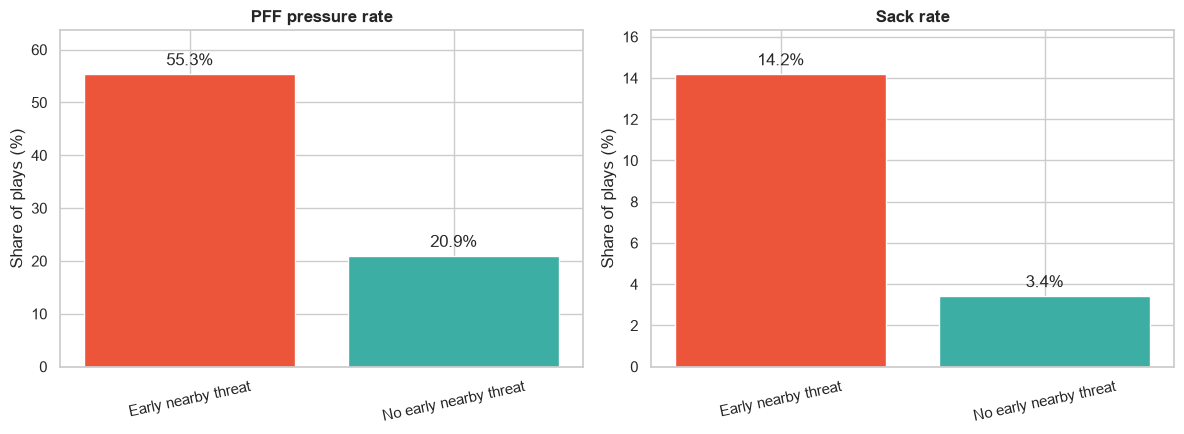

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#3CAEA3" if "No early" in label else "#ED553B" for label in status_rates["Pocket status"]]

for ax, column, title in [
    (axes[0], "pff_pressure_rate", "PFF pressure rate"),
    (axes[1], "sack_rate", "Sack rate"),
]:
    bars = ax.bar(status_rates["Pocket status"], status_rates[column] * 100, color=colors)
    ax.bar_label(bars, labels=[f"{value:.1%}" for value in status_rates[column]], padding=4)
    ax.set(title=title, ylabel="Share of plays (%)", xlabel="")
    ax.tick_params(axis="x", rotation=12)
    ax.set_ylim(0, max(status_rates[column].max() * 115, 1))
plt.tight_layout()
plt.show()

**Interpretation:** if early nearby threats produce substantially more PFF pressure and sacks, the simple tracking definition contains useful signal. It is still not an attribution model: the chart does not tell us whether the cause was one blocker, a protection call, a free rusher, or quarterback movement.

## 7. How a typical pocket changes over time

The following chart reports median dimensions among traditional dropbacks still active at each checkpoint. Later checkpoints contain fewer plays because many passes have already been released.

In [28]:
shape_rows = []
for second, suffix in [(0.0, None), (1.0, "1_0s"), (2.0, "2_0s"), (2.5, "2_5s"), (3.0, "3_0s")]:
    width_col = "initial_width" if suffix is None else f"pocket_width_{suffix}"
    cushion_col = "initial_cushion" if suffix is None else f"front_cushion_{suffix}"
    valid = traditional[[width_col, cushion_col]].dropna()
    shape_rows.append({
        "Seconds": second, "Pocket width": valid[width_col].median(),
        "Front cushion": valid[cushion_col].median(), "Active plays": len(valid),
    })
typical_shape = pd.DataFrame(shape_rows)
typical_shape

,Seconds,Pocket width,Front cushion,Active plays
0,0.0,6.21,3.644,6524
1,1.0,7.11,3.356,6521
2,2.0,6.63,3.436,5622
3,2.5,5.99,3.108,3963
4,3.0,5.76,2.806,2238


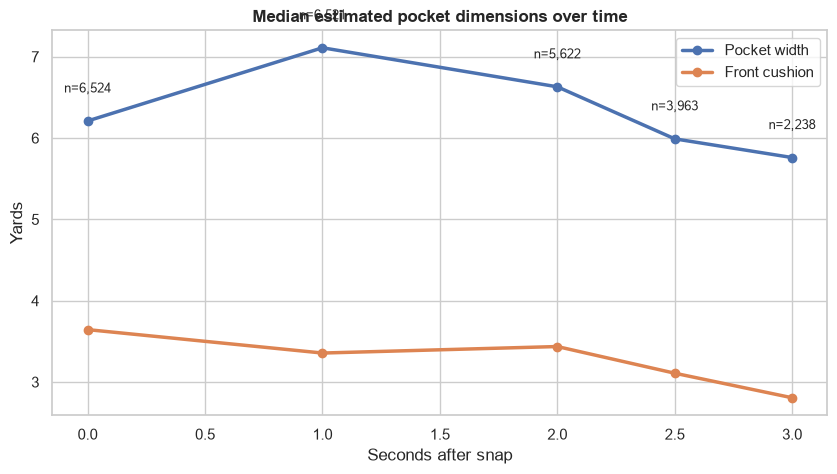

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(typical_shape["Seconds"], typical_shape["Pocket width"], marker="o", linewidth=2.5, label="Pocket width")
ax.plot(typical_shape["Seconds"], typical_shape["Front cushion"], marker="o", linewidth=2.5, label="Front cushion")
for row in typical_shape.itertuples():
    ax.text(row.Seconds, max(row._2, row._3) + 0.35, f"n={row._4:,}", ha="center", fontsize=9)
ax.set(title="Median estimated pocket dimensions over time",
       xlabel="Seconds after snap", ylabel="Yards")
ax.legend()
plt.show()

**What this means:** the pocket is not fully formed at the snap. It develops as the quarterback drops and blockers set, then changes as rushers apply force. The sample count above each point prevents us from forgetting that long-lasting plays are a selected subset rather than the average pass play.

## 8. Is pocket analysis useful to both coordinators?

**Yes—very useful to both, but they ask opposite questions.**

### Offensive coordinator and offensive-line coach

| Question | Pocket-analysis output | Possible decision |
|---|---|---|
| Where does protection fail first? | Left edge, right edge, or interior breach time | Change help or slide direction |
| How long is the QB usually clean? | Clean-pocket survival curve | Match concepts to realistic protection time |
| Who needs help? | Context-adjusted blocker loss patterns | Add a chip, back, or tight end |
| Does the QB create pressure? | Lateral/depth movement before breach | Adjust footwork, landmarks, or progression timing |
| Which calls protect best? | Pocket integrity by formation and protection | Refine the weekly call sheet |

### Defensive coordinator and defensive-line coach

| Question | Pocket-analysis output | Possible decision |
|---|---|---|
| Which rush plan creates the earliest threat? | Threat time by front or pressure call | Choose rush packages by situation |
| Where is the offense vulnerable? | Breach lane and blocker matchup | Target a protection weakness |
| Who wins even without sacks? | Quick-win and compression rates | Evaluate disruptive defenders fairly |
| Do stunts create space for teammates? | First and second rusher paths | Improve games and pass-offs |
| Are rush lanes disciplined? | Pocket shape plus QB escape direction | Balance pressure with containment |

The same play can therefore produce two reports: **“How did we preserve the pocket?”** for the offense and **“How did we deform the pocket?”** for the defense.

## 9. Recommended next-stage metrics

### Offensive: Pocket Integrity Score
Combine interpretable components rather than hiding everything in one model:

- **Clean-window rate:** pocket survives through 2.0, 2.5, and 3.0 seconds.
- **Front-cushion retained:** ability to prevent interior push.
- **Edge integrity:** time until the left or right boundary is lost.
- **QB operating space:** usable width and depth at release.
- **Recovery rate:** protection stabilizes after an initial deformation.

### Defensive: Pocket Disruption Score

- **Time to first threat:** lower is better for the defense.
- **Quick-win rate:** threat created before the expected throw window.
- **Compression generated:** pocket space removed without requiring a sack.
- **Pressure conversion:** threats becoming hurries, hits, or sacks.
- **Containment:** pressure created without opening an easy escape lane.

### Shared reporting principle
Every score should link back to the underlying plays. Coordinators and scouts should be able to move from a rate to representative film-like tracking examples: early wins, late wins, clean protections, stunts, free rushers, and quarterback-created pressure.

## 10. Limitations and guardrails

- The triangular pocket is an **explainable approximation**, not an official boundary.
- Distance alone cannot determine blocker responsibility or whether a defender has a clear path.
- Double teams, chips, stunts, switches, and unblocked rushers need explicit treatment.
- Planned rollouts must be separated from forced pocket exits.
- Coverage and quarterback decision-making affect how long protection is required.
- Player grades need minimum-rep rules, role/position adjustment, and uncertainty ranges.
- The 2.5-yard and 2.5-second references must be calibrated with PFF outcomes and representative film review.

### Bottom line
Pocket analysis is valuable to **both sides of the ball**. The current data is rich enough to measure pocket shape, timing, pressure proximity, and quarterback movement. The next analytical step should divide the pocket into left edge, interior, and right edge, then assign each deformation to blocker–rusher interactions while preserving play context.